# IDCIO 组合干预推荐全流程

本 notebook 演示 `causalmt.IDCIO`（论文方法）的端到端用法：在 EconML multi_attribution 数据上做
「Tech Support × Discount」的组合干预推荐。

三阶段管线：
1. **原子效应估计**：用 `GACRNet` 在 `split="atomic"` 样本上训练，估计 τ̂_1 (Tech Support), τ̂_2 (Discount)
2. **交互效应学习**：用 `IDCIO.fit_interaction` 在 `split="combined"` 样本上拟合 τ̂_{1,2}
3. **QUBO 求解**：对每个新样本，搜索 4 种 binary action 的最优组合

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from causalmt import GACRNet, IDCIO
from causalmt.data import load_multi_attribution

# 中文标签字体（按平台依次回退）
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Heiti TC", "STHeiti", "Microsoft YaHei", "SimHei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# 用扩展版（含 tau_12_true 用于评估），改成你自己的路径
DATA_PATH = Path("~/Graduate/Work/毕业论文/数据集/multi_attribution_synthetic.csv").expanduser()

## 阶段 1：训练 GACRNet（原子效应）

用 `split="atomic"` 排除两干预都=1 的样本。

In [2]:
atomic = load_multi_attribution(DATA_PATH, split="atomic")
print(atomic)
print(f"干预分布: {dict(zip(*np.unique(atomic.t, return_counts=True)))}")

CausalDataset(name='multi_attribution_atomic', n=1456, d=8, K=3, has_potential=True, has_cate_true=True)
干预分布: {0: 517, 1: 462, 2: 477}


In [3]:
# 标准化连续特征 + 输出
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler().fit(atomic.x[:, 4:])
x_norm = atomic.x.copy()
x_norm[:, 4:] = x_scaler.transform(atomic.x[:, 4:])

y_scaler = StandardScaler().fit(atomic.y.reshape(-1, 1))
y_norm = y_scaler.transform(atomic.y.reshape(-1, 1)).flatten().astype(np.float32)

X_tr, X_te, t_tr, t_te, y_tr, y_te = train_test_split(
    x_norm, atomic.t, y_norm, test_size=0.2, random_state=42, stratify=atomic.t,
)

est = GACRNet(
    num_treatments=3,
    hidden_dim=200, head_hidden=100,
    use_mmd=True, use_tarreg=True,
    epochs=300, batch_size=128, lr=1e-3,
    early_stopping_patience=30, verbose=False, random_state=42,
)
est.fit(X_tr.astype(np.float32), t_tr, y_tr)
print(f"GACRNet 训练完成 @ epoch {est.history_['best_epoch']}")
print(f"ATE(T1 vs ctrl): {est.estimate_ate(X_te.astype(np.float32), treatment_a=1) * y_scaler.scale_[0]:.3f}")
print(f"ATE(T2 vs ctrl): {est.estimate_ate(X_te.astype(np.float32), treatment_a=2) * y_scaler.scale_[0]:.3f}")

GACRNet 训练完成 @ epoch 116
ATE(T1 vs ctrl): 8.080
ATE(T2 vs ctrl): 3.750


## 阶段 2：训练 IDCIO 交互项

用 `split="combined"` 仅含组合干预的样本，配合 GACRNet 学习交互项 τ_{1,2}。

In [4]:
combined = load_multi_attribution(DATA_PATH, split="combined")
print(combined)

# 同样的特征标准化
x_combined = combined.x.copy()
x_combined[:, 4:] = x_scaler.transform(combined.x[:, 4:])
x_combined = x_combined.astype(np.float32)
y_combined = y_scaler.transform(combined.y.reshape(-1, 1)).flatten().astype(np.float32)

CausalDataset(name='multi_attribution_combined', n=544, d=8, K=2, has_cate_true=True)


In [5]:
rec = IDCIO.from_estimator(
    atomic_estimator=est,
    interaction_hidden=(100, 50),
    interaction_dropout=0.2,    # 启用以便后面的 MC Dropout
    epochs=200, batch_size=64, lr=1e-3,
    early_stopping_patience=25,
    use_mc_dropout=True, mc_samples=50,
    verbose=False, random_state=42,
)
rec.fit_interaction(x_combined, y_combined, treatment_pairs=[(0, 1)])
print("IDCIO 交互项训练完成")

IDCIO 交互项训练完成


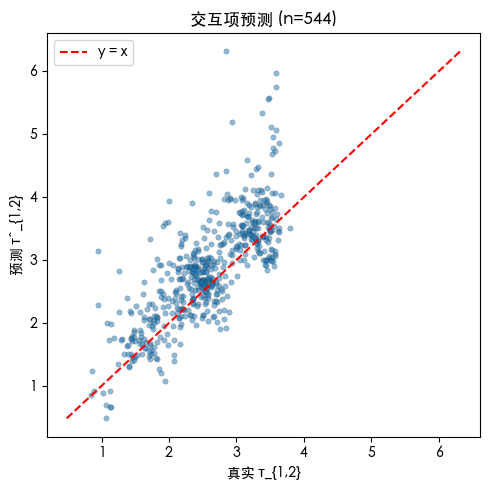

In [6]:
# 可视化预测交互项 vs 真值（如果有）
inter_pred = rec.predict_interactions(x_combined)[(0, 1)] * y_scaler.scale_[0]

if "tau_12_true" in combined.extra:
    inter_true = combined.extra["tau_12_true"]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(inter_true, inter_pred, alpha=0.5, s=15, edgecolor="k", linewidth=0.2)
    lims = [min(inter_true.min(), inter_pred.min()), max(inter_true.max(), inter_pred.max())]
    ax.plot(lims, lims, "r--", label="y = x")
    ax.set_xlabel("真实 τ_{1,2}")
    ax.set_ylabel("预测 τ̂_{1,2}")
    ax.set_title(f"交互项预测 (n={len(inter_true)})")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(6, 3))
    plt.hist(inter_pred, bins=40, edgecolor="k")
    plt.xlabel("预测 τ̂_{1,2}")
    plt.title("交互项预测分布")
    plt.tight_layout()
    plt.show()

## 阶段 3：QUBO 推荐

对全体测试样本搜索最优 (Tech Support, Discount) 组合。先不带成本看看分布。

In [7]:
actions = rec.recommend(X_te.astype(np.float32), method="exhaustive", maximize=True)
print(f"推荐 shape: {actions.shape}")

combo_names = {
    (0, 0): "无干预",
    (1, 0): "仅 Tech Support",
    (0, 1): "仅 Discount",
    (1, 1): "两个都给",
}
from collections import Counter
counts = Counter(tuple(a) for a in actions)
print("\n推荐分布（零成本）:")
for combo, name in combo_names.items():
    print(f"  {name}: {counts.get(combo, 0)} ({counts.get(combo, 0)/len(actions):.1%})")

推荐 shape: (292, 2)

推荐分布（零成本）:
  无干预: 0 (0.0%)
  仅 Tech Support: 0 (0.0%)
  仅 Discount: 0 (0.0%)
  两个都给: 292 (100.0%)


### 加上动态成本

把每个干预的成本设为其原子效应分布的 0.5 分位数（即至少要让一半的客户能赚回成本才推荐）。

In [8]:
tau1_pred = est.estimate_cate(X_te.astype(np.float32), treatment_a=1)
tau2_pred = est.estimate_cate(X_te.astype(np.float32), treatment_a=2)
costs = np.array([np.quantile(np.abs(tau1_pred), 0.5), np.quantile(np.abs(tau2_pred), 0.5)])
print(f"动态成本: c1={costs[0]:.3f}, c2={costs[1]:.3f}")

actions_cost = rec.recommend(
    X_te.astype(np.float32), costs=costs, method="exhaustive", maximize=True,
)
counts_cost = Counter(tuple(a) for a in actions_cost)
print("\n推荐分布（带成本）:")
for combo, name in combo_names.items():
    print(f"  {name}: {counts_cost.get(combo, 0)} ({counts_cost.get(combo, 0)/len(actions_cost):.1%})")

动态成本: c1=1.371, c2=0.634

推荐分布（带成本）:
  无干预: 26 (8.9%)
  仅 Tech Support: 0 (0.0%)
  仅 Discount: 0 (0.0%)
  两个都给: 266 (91.1%)


## 阶段 4：带不确定性的推荐

用 MC Dropout 多次采样，统计每个样本的 action 稳定性作为置信度。

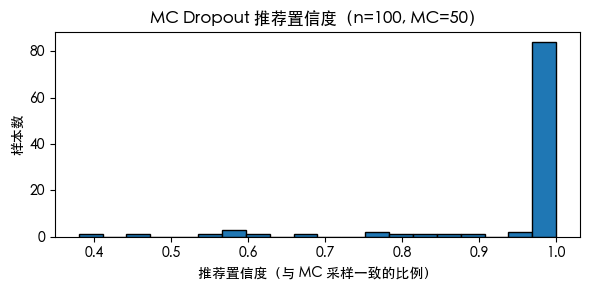

高置信样本（confidence ≥ 0.9）: 86 / 100
低置信样本（confidence < 0.5）: 2 / 100


In [9]:
actions_mc, confidence = rec.recommend(
    X_te[:100].astype(np.float32),
    costs=costs,
    method="exhaustive",
    maximize=True,
    return_uncertainty=True,
)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(confidence, bins=20, edgecolor="k")
ax.set_xlabel("推荐置信度（与 MC 采样一致的比例）")
ax.set_ylabel("样本数")
ax.set_title(f"MC Dropout 推荐置信度（n=100, MC={rec.config.mc_samples}）")
plt.tight_layout()
plt.show()

print(f"高置信样本（confidence ≥ 0.9）: {(confidence >= 0.9).sum()} / 100")
print(f"低置信样本（confidence < 0.5）: {(confidence < 0.5).sum()} / 100")

## 总结

本 notebook 完整展示了 `GACRNet + IDCIO` 在多干预归因数据上的端到端用法：

| 步骤 | API 调用 |
|---|---|
| 原子效应估计 | `GACRNet(num_treatments=3).fit(...)` |
| 交互项学习 | `IDCIO.from_estimator(est).fit_interaction(...)` |
| 推荐 | `rec.recommend(x, costs=c, method="exhaustive")` |
| 不确定性 | `rec.recommend(x, return_uncertainty=True)` |

完整代码总共不到 50 行，对比研究原型代码（1000+ 行）大幅降低了使用门槛。